In [1]:
"""
==========================================================
SOFISM on a sample simulated with tttrlib's photon simulator
==========================================================

SOFISM -- super-resolution optical fluctuation image scanning microscopy
(Sroda et al., `Optica 7, 1308 (2020) <https://doi.org/10.1364/OPTICA.399600>`_)
-- multiplies two independent resolution mechanisms. ISM reassigns each detector
element's image by half its offset; SOFI replaces the mean signal by a
second-order cumulant of the temporal fluctuations, whose effective PSF is the
product of two elements' PSFs. A pair of elements acts as one *virtual* detector
midway between them, so the pair's correlation image is reassigned by
:math:`\\vec{v}_{ij} = (\\vec{v}_i + \\vec{v}_j)/2`.

Everything rests on the emitters fluctuating *independently*. This example makes
that testable by running the same geometry twice -- once with blinking
fluorophores, once with them permanently on -- and showing that the second
carries no SOFISM signal at all.

The whole acquisition comes from tttrlib's photon simulator:

* the **array detector** is one detection ``SimGrid`` per routing channel, each
  displaced on a lattice. A photon is assigned to channel *j* with probability
  proportional to :math:`q_j \\cdot \\mathrm{det}_j(\\vec{r})`, so an emitter
  under one element lands in that element's channel -- this *is* the ISM
  geometry, not a model of it. Note that ``SimSpecies.q`` needs one brightness
  per channel; a single value silently routes everything to channel 0.
* **blinking** is two species, bright and dark, coupled by the spontaneous rate
  matrix ``k_nrad``. The rates are chosen so an emitter switches several times
  within one pixel dwell, which is the condition scanning SOFISM lives or dies
  by -- fluctuations slower than the dwell leave nothing to correlate.
"""

import numpy as np
import matplotlib.pyplot as plt

import tttrlib

In [2]:
# Geometry, and the timescales that matter
# ----------------------------------------
N = 20                 # pixels per side
PX = 0.08              # micrometres per pixel
SIDE = 3               # detector elements per side
N_DET = SIDE * SIDE
PITCH = 0.16           # element spacing projected into the sample, micrometres
N_TIME = 32            # time bins per scan position
DWELL = 0.004          # dwell per time bin (simulator time units)

# blinking rates: mean bright and dark times of a few time bins each, so several
# transitions happen inside one pixel dwell of N_TIME * DWELL
K_OFF, K_ON = 60.0, 90.0
BRIGHTNESS = 5e4

SEPARATION = 0.20      # micrometres between the two emitters
CENTRE = (N - 1) / 2 * PX

print(f"pixel dwell        : {N_TIME * DWELL:.3f}")
print(f"mean bright / dark : {1 / K_OFF:.4f} / {1 / K_ON:.4f}  "
      f"({N_TIME * DWELL * K_OFF:.0f} on-off cycles per dwell)")


def acquire(blinking, seed=1):
    """Scan the sample and return the (n_time, n_det, ny, nx) cube SOFISM takes."""
    system = tttrlib.SimSystem()

    bright = tttrlib.SimSpecies()
    bright.D = 0.0                                     # immobile
    bright.q = tttrlib.VectorDouble([BRIGHTNESS] * N_DET)   # one per channel
    system.add_species(bright)

    if blinking:
        dark = tttrlib.SimSpecies()
        dark.D = 0.0
        dark.q = tttrlib.VectorDouble([0.0] * N_DET)
        system.add_species(dark)
        # spontaneous transitions, row-major i -> j over the two species
        system.set_rate_matrices(
            tttrlib.VectorDouble([0.0] * 4),
            tttrlib.VectorDouble([0.0, K_OFF, K_ON, 0.0]),
        )
    else:
        system.set_rate_matrices(tttrlib.VectorDouble([0.0]),
                                 tttrlib.VectorDouble([0.0]))
    system.set_background(tttrlib.VectorDouble([0.0] * N_DET))

    for dx in (-SEPARATION / 2, SEPARATION / 2):
        system.add_fluorophore(CENTRE + dx, CENTRE, 0.0, 0, False)

    excitation = tttrlib.SimGrid.gaussian3d(0.14, 1.0, 0.6, 1.0, 0.02, 1.0)
    detection = []
    for row in range(SIDE):
        for col in range(SIDE):
            g = tttrlib.SimGrid.gaussian3d(0.16, 1.0, 0.6, 1.0, 0.02, 1.0)
            g.x0 += (col - (SIDE - 1) / 2) * PITCH      # displace the element
            g.y0 += (row - (SIDE - 1) / 2) * PITCH
            detection.append(g)

    settings = tttrlib.SimIntegrator()
    settings.dt = DWELL / 4
    settings.n_channels = N_DET
    settings.n_ph_max = 10 ** 9
    settings.seed_emission = seed
    settings.seed_diffusion = seed + 1

    engine = tttrlib.SimEngine(system, excitation,
                               tttrlib.VectorSimGrid(detection), settings)
    engine.run_scan(tttrlib.SimScanner.uniform(
        N, N, dwell=DWELL * N_TIME, pixel_dx=PX, pixel_dy=PX,
        origin_x=0.0, origin_y=0.0,
        markers=tttrlib.SimMarkerConfig(), bidirectional=False))

    # bin the photon stream into (time, detector, y, x)
    photons = engine.photons()
    is_photon = np.asarray(photons["event_type"]) == 0
    t = (np.asarray(photons["macro_window"], dtype=float)[is_photon] * settings.dt
         + np.asarray(photons["arrival_time"], dtype=float)[is_photon])
    ch = np.asarray(photons["channel"], dtype=np.int64)[is_photon]

    total_dwell = DWELL * N_TIME
    flat = np.clip((t / total_dwell).astype(np.int64), 0, N * N - 1)
    sub = np.clip(((t - flat * total_dwell) / DWELL).astype(np.int64), 0, N_TIME - 1)

    cube = np.zeros((N_TIME, N_DET, N, N))
    np.add.at(cube, (sub, np.clip(ch, 0, N_DET - 1), flat // N, flat % N), 1.0)
    return cube


blinking_cube = acquire(blinking=True, seed=1)
static_cube = acquire(blinking=False, seed=7)
print(f"\nblinking : {blinking_cube.sum():.4g} photons")
print(f"static   : {static_cube.sum():.4g} photons")
print(f"per element (blinking): {blinking_cube.sum(axis=(0, 2, 3)).astype(int)}")

pixel dwell        : 0.128
mean bright / dark : 0.0167 / 0.0111  (8 on-off cycles per dwell)

blinking : 5.831e+04 photons
static   : 9.45e+04 photons
per element (blinking): [ 2318  7149  2341  7235 21932  7191  2203  5929  2009]


In [3]:
# Reconstruct
# -----------
def reconstruct(cube):
    time_averaged = cube.mean(axis=0)
    confocal = time_averaged.sum(axis=0)
    apr = tttrlib.CLSMSuperRes.apr_reconstruction(time_averaged, usf=6)[0]
    sofism = tttrlib.CLSMSuperRes.sofism_reconstruction(cube, lag=0, usf=6)
    return confocal, apr, sofism


confocal, apr, sofism = reconstruct(blinking_cube)
_, _, sofism_static = reconstruct(static_cube)

print(f"\npeak SOFISM  blinking {np.abs(sofism).max():.4g}"
      f"   static {np.abs(sofism_static).max():.4g}"
      f"   ratio {np.abs(sofism).max() / max(np.abs(sofism_static).max(), 1e-12):.0f}x")


def profile(img):
    band = np.clip(img, 0, None)[N // 2 - 1:N // 2 + 2].mean(axis=0)
    return (band - band.min()) / (band.max() - band.min() + 1e-12)


peak SOFISM  blinking 5955   static 44.06   ratio 135x


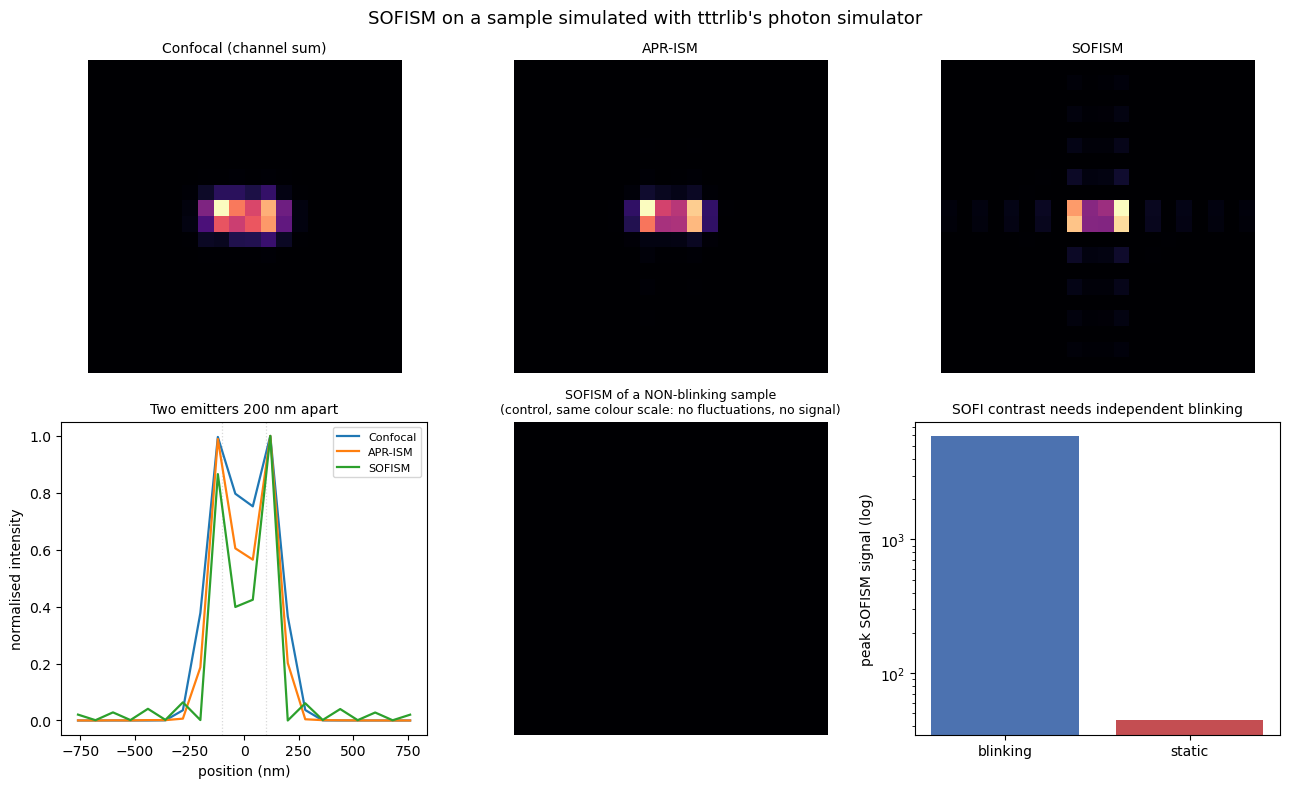

In [4]:
# The comparison. The dip between the two emitters deepens from confocal to ISM
# to SOFISM; the static sample is the control.
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (title, img) in zip(axes[0], [
    ("Confocal (channel sum)", confocal),
    ("APR-ISM", apr),
    ("SOFISM", np.clip(sofism, 0, None)),
]):
    ax.imshow(np.clip(img, 0, None), cmap="magma", origin="lower")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

ax = axes[1, 0]
x_nm = (np.arange(N) - (N - 1) / 2) * PX * 1000
for label, img in (("Confocal", confocal), ("APR-ISM", apr), ("SOFISM", sofism)):
    ax.plot(x_nm, profile(img), lw=1.6, label=label)
for pos in (-SEPARATION / 2, SEPARATION / 2):
    ax.axvline(pos * 1000, color="0.85", ls=":", lw=0.9, zorder=0)
ax.set_xlabel("position (nm)")
ax.set_ylabel("normalised intensity")
ax.set_title(f"Two emitters {SEPARATION * 1000:.0f} nm apart", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1, 1]
# the same colour scale as the SOFISM panel above -- letting this one autoscale
# would make 135x less signal look like a reconstruction
ax.imshow(np.clip(sofism_static, 0, None), cmap="magma", origin="lower",
          vmin=0, vmax=np.clip(sofism, 0, None).max())
ax.set_title("SOFISM of a NON-blinking sample\n"
             "(control, same colour scale: no fluctuations, no signal)",
             fontsize=9)
ax.axis("off")

ax = axes[1, 2]
ax.bar(["blinking", "static"],
       [np.abs(sofism).max(), np.abs(sofism_static).max()],
       color=["#4c72b0", "#c44e52"])
ax.set_yscale("log")
ax.set_ylabel("peak SOFISM signal (log)")
ax.set_title("SOFI contrast needs independent blinking", fontsize=10)

fig.suptitle("SOFISM on a sample simulated with tttrlib's photon simulator",
             fontsize=13)
plt.tight_layout()
plt.show()